In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

In [4]:
df  = pd.read_csv(r"D:\AI Business Recomendation\datasets\dataset_ml_structured.csv")

In [6]:
df.head()
print(df.columns)

Index(['target_business_type_id', 'target_business_type', 'osm_id',
       'feature_has_name', 'feature_has_house_number', 'feature_has_street',
       'feature_has_suburb', 'feature_has_city', 'feature_has_postcode',
       'feature_has_any_address', 'feature_osm_type_node',
       'feature_osm_type_relation', 'feature_osm_type_way',
       'feature_category_amenity', 'feature_category_craft',
       'feature_category_healthcare', 'feature_category_office',
       'feature_category_shop', 'feature_lat', 'feature_lon',
       'feature_pois_500m', 'feature_same_category_500m',
       'feature_same_subcategory_500m', 'feature_unique_subcategory_500m',
       'feature_services_500m', 'feature_transport_500m', 'feature_roads_500m',
       'feature_major_roads_500m', 'feature_landuse_residential_500m',
       'feature_landuse_commercial_500m', 'feature_landuse_industrial_500m',
       'feature_landuse_retail_500m', 'feature_landuse_mixed_500m',
       'feature_landuse_farmland_500m', 'featu

In [7]:
df = df.drop(["osm_id"], axis=1)

In [ ]:
X = df.drop(["target_business_type", "target_business_type_id"], axis=1)
y = df["target_business_type"]

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.7176616915422885


In [16]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[379  18   0   5   0   3   0   0   0  16   5   0   0  17   0   0   0]
 [  7   2   0   1   0   0   0   0   0   1   0   0   0   5   0   0   0]
 [  0   0   6   0   2   0   0   1   0   0   0   1   1   0  10   0   2]
 [  6   0   0   8   0   0   0   0   0  11   0   0   0   0   0   0   0]
 [  0   0   3   0   2   0   0   0   0   0   0   0   0   0   2   0   1]
 [  3   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   1   0   0   3   0   0   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0  10   0   0   0   0   0   0   0   0]
 [ 15   2   0  10   0   0   0   0   0  54   0   0   0   0   0   0   0]
 [  1   1   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   1   2   0   1   0   1]
 [  0   0   4   0   0   0   0   0   0   0   0   0  10   0   0   0   1]
 [ 21   2   0   1   0   1   0   0   0   5   0   0   0  13   0   0   0]
 [  0 

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       443
           1       0.08      0.12      0.10        16
           2       0.27      0.26      0.27        23
           3       0.32      0.32      0.32        25
           4       0.22      0.25      0.24         8
           5       0.20      0.25      0.22         4
           6       0.00      0.00      0.00         1
           7       0.27      0.60      0.38         5
           8       1.00      1.00      1.00        10
           9       0.62      0.67      0.64        81
          11       0.17      0.33      0.22         3
          12       0.50      0.20      0.29         5
          13       0.59      0.67      0.62        15
          14       0.37      0.30      0.33        43
          15       0.74      0.65      0.69        80
          16       1.00      1.00      1.00        32
          17       0.23      0.30      0.26        10

    accuracy              

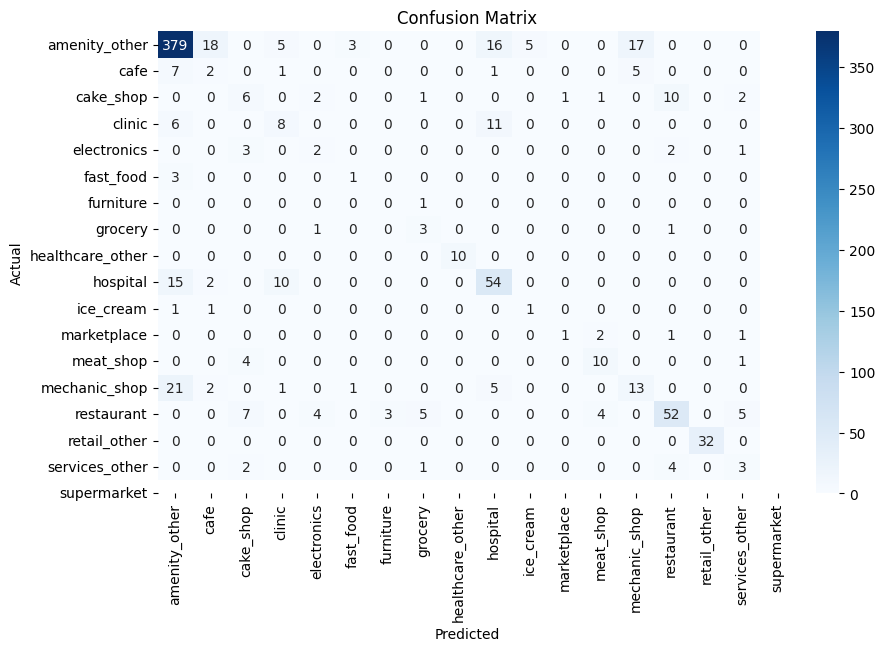

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()